[OK] DecisionTree processado com sucesso (70 pacientes).
[OK] RandomForest processado com sucesso (70 pacientes).
[OK] SVC processado com sucesso (70 pacientes).
[OK] XGBoost processado com sucesso (70 pacientes).
[OK] CatBoost processado com sucesso (70 pacientes).
[OK] LightGBM processado com sucesso (70 pacientes).

      Modelo Acurácia Precisão Recall F1-Score  Pacientes
DecisionTree   0.6714   0.7000 0.6000   0.6462         70
RandomForest   0.6571   0.6486 0.6857   0.6667         70
         SVC   0.6714   0.6875 0.6286   0.6567         70
     XGBoost   0.7429   0.7576 0.7143   0.7353         70
    CatBoost   0.6857   0.6585 0.7714   0.7105         70
    LightGBM   0.7143   0.7027 0.7429   0.7222         70


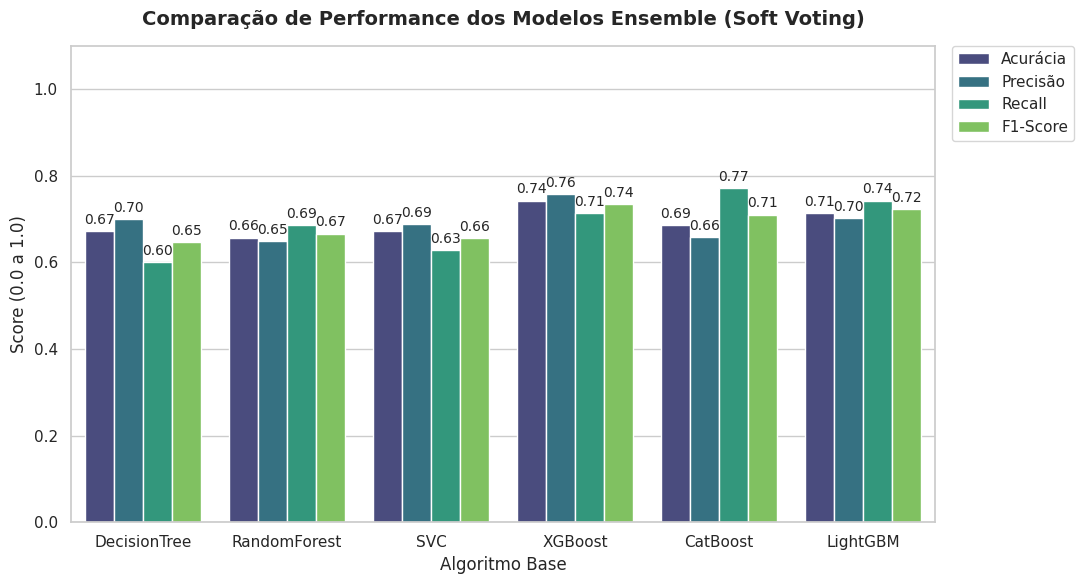

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# ==============================================================================
# 1. MAPEAMENTO DOS ARQUIVOS GERADOS
# ==============================================================================
modelos_arquivos = {
    'DecisionTree': '/home/dani/Documentos/PEP/ensemble_results_dt.csv',
    'RandomForest': '/home/dani/Documentos/PEP/ensemble_results_RF.csv',
    'SVC': '/home/dani/Documentos/PEP/ensemble_results_SVC.csv',
    'XGBoost': '/home/dani/Documentos/PEP/ensemble_results_XG.csv',
    'CatBoost': '/home/dani/Documentos/PEP/ensemble_results_CB.csv',
    'LightGBM': '/home/dani/Documentos/PEP/ensemble_results_GBM.csv'
}

# Dicionário para armazenar as métricas consolidadas
metricas_consolidadas = []

# ==============================================================================
# 2. PROCESSAMENTO E EXTRAÇÃO DE MÉTRICAS
# ==============================================================================
for nome_modelo, caminho_csv in modelos_arquivos.items():
    try:
        df = pd.read_csv(caminho_csv)
        
        y_true = df['True_Label']
        y_pred = df['Predicted_Class']
        
        # Cálculo das métricas para a classe 1 (AD)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        # Guardando os dados estruturados
        metricas_consolidadas.append({
            'Modelo': nome_modelo,
            'Acurácia': acc,
            'Precisão': prec,
            'Recall': rec,
            'F1-Score': f1,
            'Pacientes': len(df)
        })
        print(f"[OK] {nome_modelo} processado com sucesso ({len(df)} pacientes).")
        
    except FileNotFoundError:
        print(f"[i] Aviso: Arquivo para o modelo {nome_modelo} não encontrado em '{caminho_csv}'. Pulando...")

# Conversão para DataFrame para facilitar manipulação e plotagem
if not metricas_consolidadas:
    print("[!] Erro crítico: Nenhum arquivo CSV de modelo foi encontrado. Rode os scripts antes.")
    raise FileNotFoundError

df_comparativo = pd.DataFrame(metricas_consolidadas)

print("\n" + "="*70)
# Formatação em tabela científica limpa
print(df_comparativo.to_string(index=False, formatters={
    'Acurácia': '{:,.4f}'.format,
    'Precisão': '{:,.4f}'.format,
    'Recall': '{:,.4f}'.format,
    'F1-Score': '{:,.4f}'.format
}))
print("="*70)

# ==============================================================================
# 3. PLOT DO GRÁFICO COMPARATIVO (MÉTRICAS PARALELAS)
# ==============================================================================
# Transformando o DataFrame para o formato 'long' exigido pelo Seaborn para barras agrupadas
df_long = df_comparativo.melt(id_vars='Modelo', value_vars=['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
                              var_name='Métrica', value_name='Valor')

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=df_long, x='Modelo', y='Valor', hue='Métrica', palette='viridis')

# Adicionando os valores textuais no topo de cada barra para facilitar leitura acadêmica
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title('Comparação de Performance dos Modelos Ensemble (Soft Voting)', fontsize=14, pad=15, weight='bold')
plt.ylim(0, 1.1) # Margem superior para não cortar os rótulos de texto
plt.ylabel('Score (0.0 a 1.0)', fontsize=12)
plt.xlabel('Algoritmo Base', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()